### Tasks

* 1. Load the Iris dataset using sklearn, apply PCA to reduce it to 2 principal components, and print the explained variance ratio for both components.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

In [2]:
df = load_iris()

In [3]:
X = df.data
y = df.target

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"Explained VR Component 1: {pca.explained_variance_ratio_[0]}")
print(f"Explained VR Component 2: {pca.explained_variance_ratio_[1]}")
print(f"Total Explained Variance: {sum(pca.explained_variance_ratio_)}")

Explained VR Component 1: 0.9246187232017341
Explained VR Component 2: 0.05306648311706383
Total Explained Variance: 0.977685206318798


* 2. Plot the 2D projection of the Iris dataset after PCA transformation, using a different color for each species, similar to how Spotify visualizes genre clusters.<br><br><em><strong>Hint:</strong> Use matplotlib's scatter() and color by target label.</em>

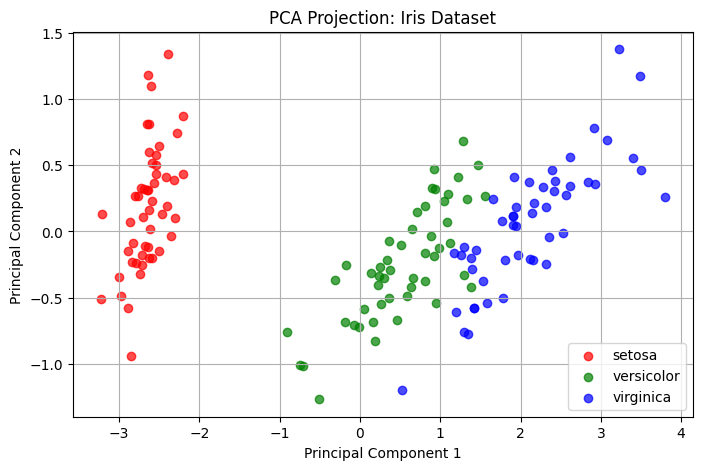

In [5]:
plt.figure(figsize=(8, 5))
colors = ["red", "green", "blue"]

for i, target_name in enumerate(df.target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], 
                color=colors[i], label=target_name, alpha=0.7)

plt.title("PCA Projection: Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

* 3. Given a dataset of Zomato restaurant ratings with 10 features, use PCA from sklearn to reduce the data to 3 components and visualize the cumulative explained variance as a line plot.

In [6]:
df = pd.read_csv(r"C:\Users\patel prit\OneDrive\Desktop\Assessment\ML\Assignment\Unsupervised\Session - 4\zomato restaurant.csv")

In [7]:
df.head()

,Unnamed: 0.1,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
0,0,0,#FeelTheROLL,Quick Bites,3.4,7,200.0,No,No,Fast Food,Bellandur,Bellandur
1,1,1,#L-81 Cafe,Quick Bites,3.9,48,400.0,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,2,2,#refuel,Cafe,3.7,37,400.0,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,3,3,'@ Biryani Central,Casual Dining,2.7,135,550.0,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,4,4,'@ The Bbq,Casual Dining,2.8,40,700.0,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur


In [8]:
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], errors="ignore")
df.head()

,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
0,#FeelTheROLL,Quick Bites,3.4,7,200.0,No,No,Fast Food,Bellandur,Bellandur
1,#L-81 Cafe,Quick Bites,3.9,48,400.0,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,#refuel,Cafe,3.7,37,400.0,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,'@ Biryani Central,Casual Dining,2.7,135,550.0,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,'@ The Bbq,Casual Dining,2.8,40,700.0,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur


In [9]:
df.isnull().sum()

restaurant name           0
restaurant type           0
rate (out of 5)          68
num of ratings            0
avg cost (two people)    57
online_order              0
table booking             0
cuisines type             0
area                      0
local address             0
dtype: int64

In [10]:
df['rate (out of 5)'] = df['rate (out of 5)'].fillna(df['rate (out of 5)'].median())
df['avg cost (two people)'] = df['avg cost (two people)'].fillna(df['avg cost (two people)'].median())

In [11]:
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = ['restaurant name', 'restaurant type', 'online_order', 'table booking', 'cuisines type', 'area', 'local address']
encoder = OrdinalEncoder()
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [14]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cumulative_variance

array([0.24426111, 0.38861299, 0.50739445])

Cumulative Explained Variance: [0.24426111 0.38861299 0.50739445]


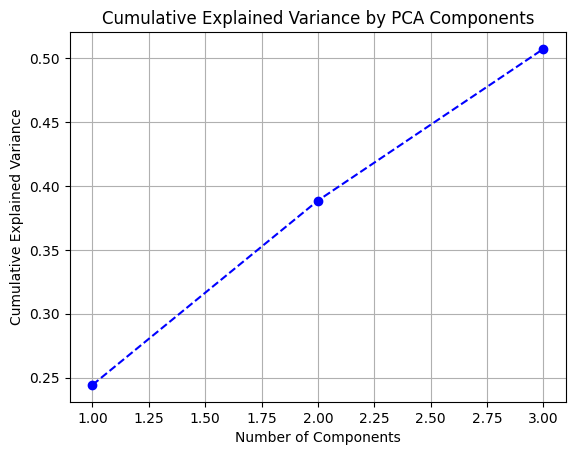

In [15]:
plt.plot([1, 2, 3], cumulative_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)

print(f"Cumulative Explained Variance: {cumulative_variance}")

* 4. Take the PCA-transformed Iris data (2 components) and run KMeans clustering with 3 clusters. Plot the clusters and centroids on the 2D PCA plot.

In [16]:
from sklearn.cluster import KMeans

kmeans_iris = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans_iris.fit_predict(X_pca)

In [17]:
centroids = kmeans_iris.cluster_centers_

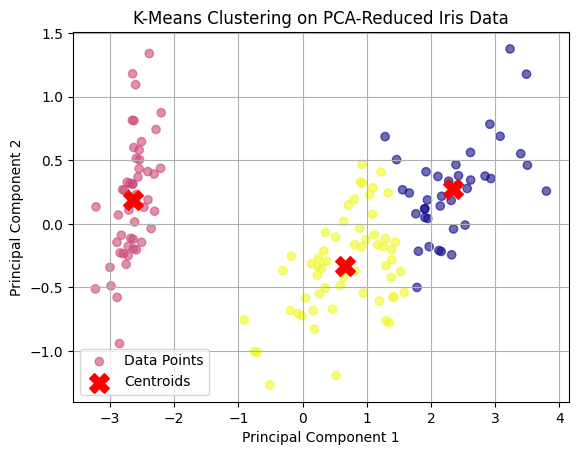

In [18]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="plasma", alpha=0.6, label="Data Points")
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", marker="X", s=200, label="Centroids")
plt.title("K-Means Clustering on PCA-Reduced Iris Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()

* 5. Use the silhouette_score function from sklearn.metrics to evaluate the quality of your KMeans clusters on the PCA-reduced Iris data. Print the silhouette score and explain what it indicates about your clustering result in 2-3 lines.

In [19]:
from sklearn.metrics import silhouette_score

In [20]:
score = silhouette_score(X_pca, kmeans_labels)

In [21]:
score

0.5976764219547994